##Installing the AutoSpectraEngine Library

In [ ]:
!pip3 install --no-cache-dir --upgrade git+https://github.com/sbarbonjr/AutoSpectraEngine.git

## Getting a example dataset

In [ ]:
!wget https://raw.githubusercontent.com/sbarbonjr/AutoSpectraEngine/refs/heads/main/auto_spectra_engine/datasets/NIR1.csv

--2025-02-10 13:13:46--  https://raw.githubusercontent.com/sbarbonjr/AutoSpectraEngine/refs/heads/main/auto_spectra_engine/datasets/NIR1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1624308 (1.5M) [text/plain]
Saving to: ‘NIR1.csv’

NIR1.csv            100%[===================>]   1.55M  --.-KB/s    in 0.05s   

2025-02-10 13:13:47 (32.6 MB/s) - ‘NIR1.csv’ saved [1624308/1624308]



## Directory Setup

In [ ]:
import os

output_directory = "/content/results"
os.makedirs(output_directory, exist_ok=True)

## Calling the Genetic Algorithm routine

In [ ]:
import auto_spectra_engine.experiment as ase

file = "NIR1.csv"
best_experiment = ase.run_ga_experiments(file, modelo="PLSDA", coluna_predicao="Adulterant", pipeline_family='NIR', budget=200, use_parallelization=True )

/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


GA Progress:   0%|          | 0/10 [00:00<?, ?it/s]

## Best Pipeline

** AutoSpectraEngine (v0.1) ::: Run Experiment **
Processing file:"NIR1.csv"
Applying MC...
Applying SNV...
Outliers removal (Isolation Forest, c =0.09)...
Plotting PCA...


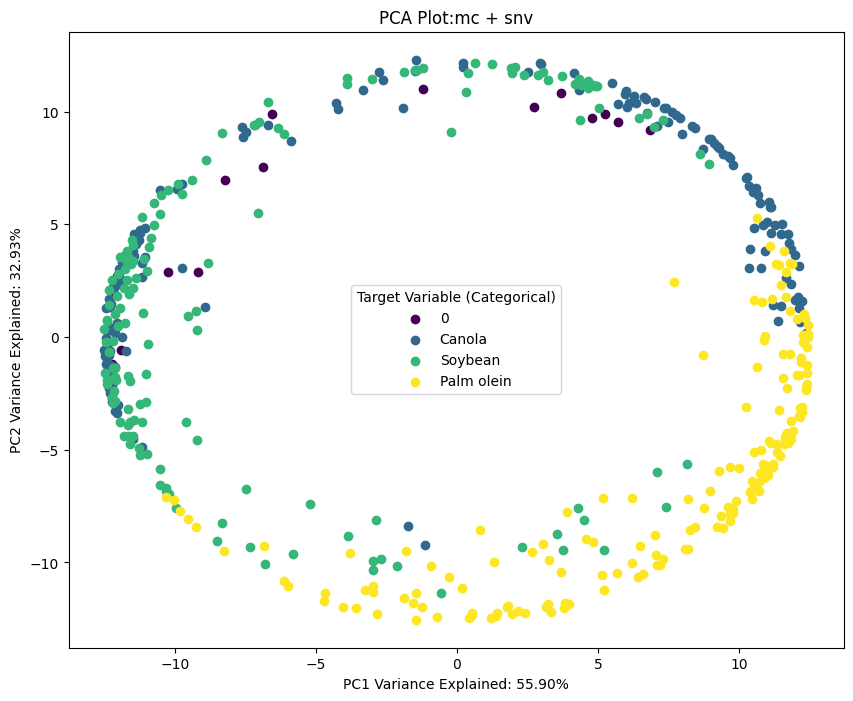

Executing PLSDA...


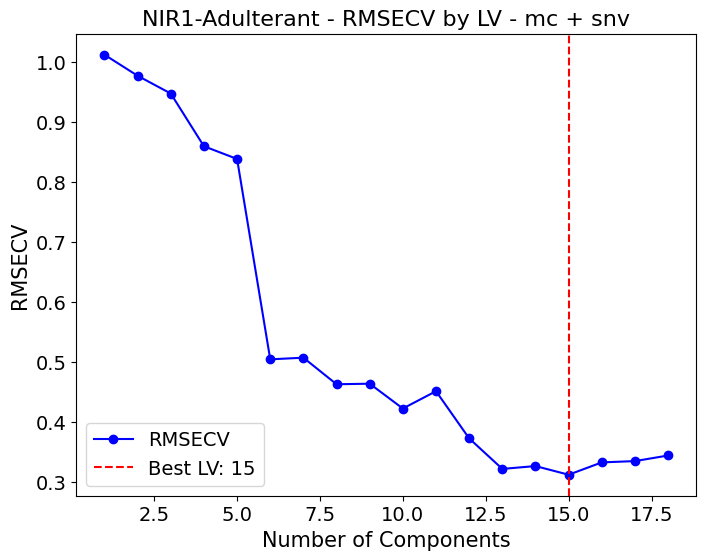

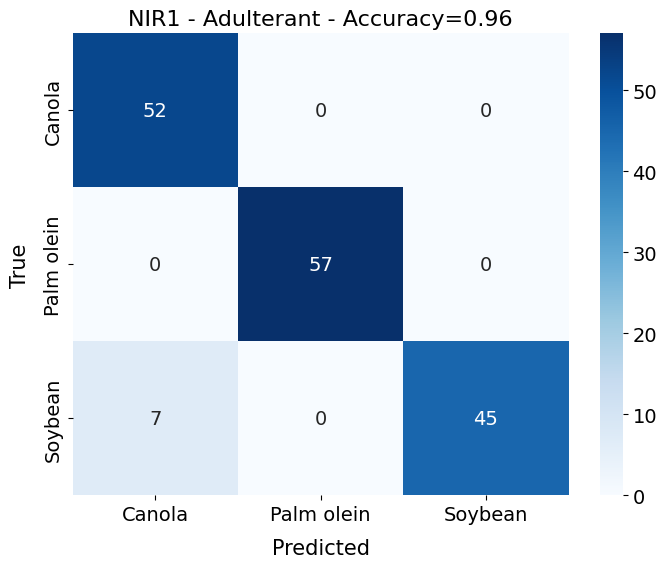

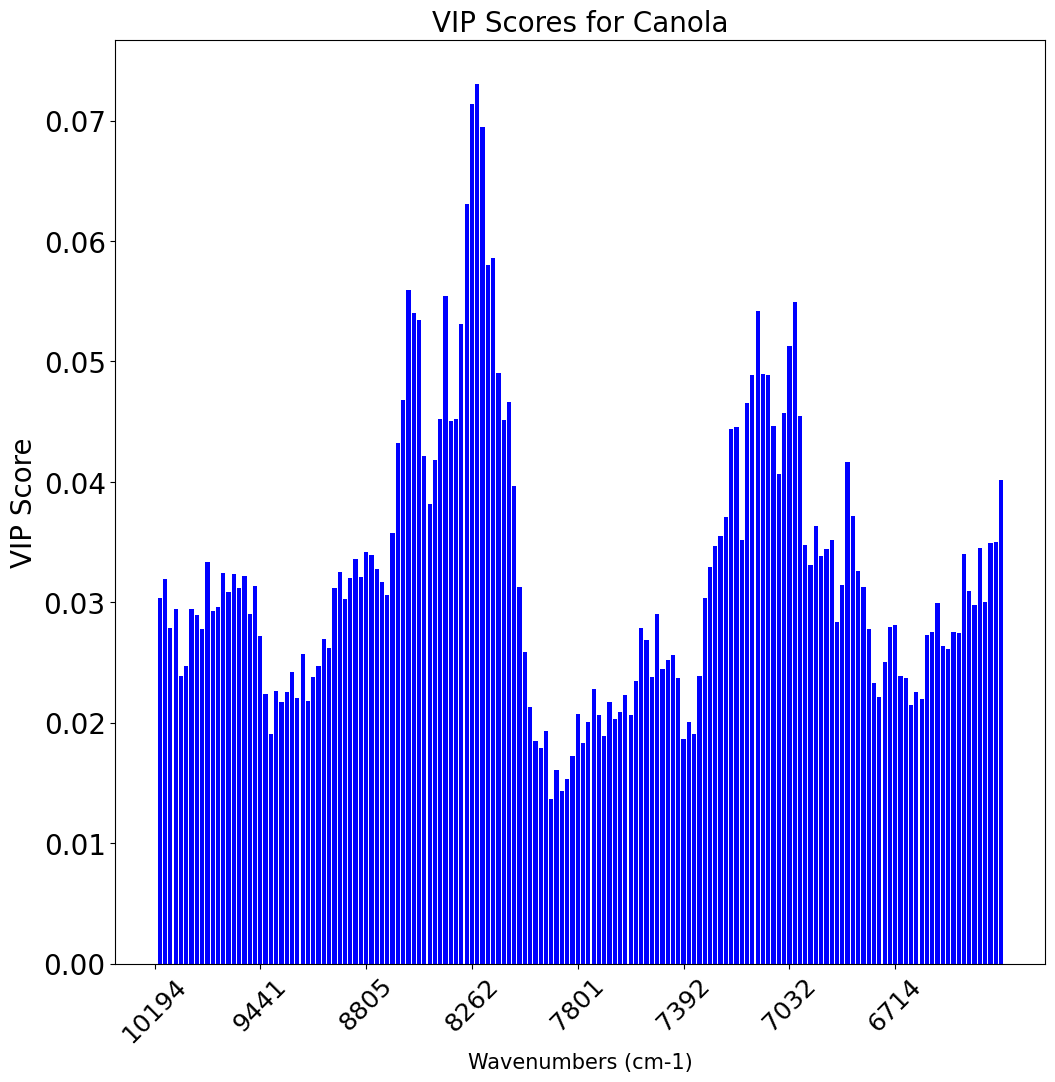

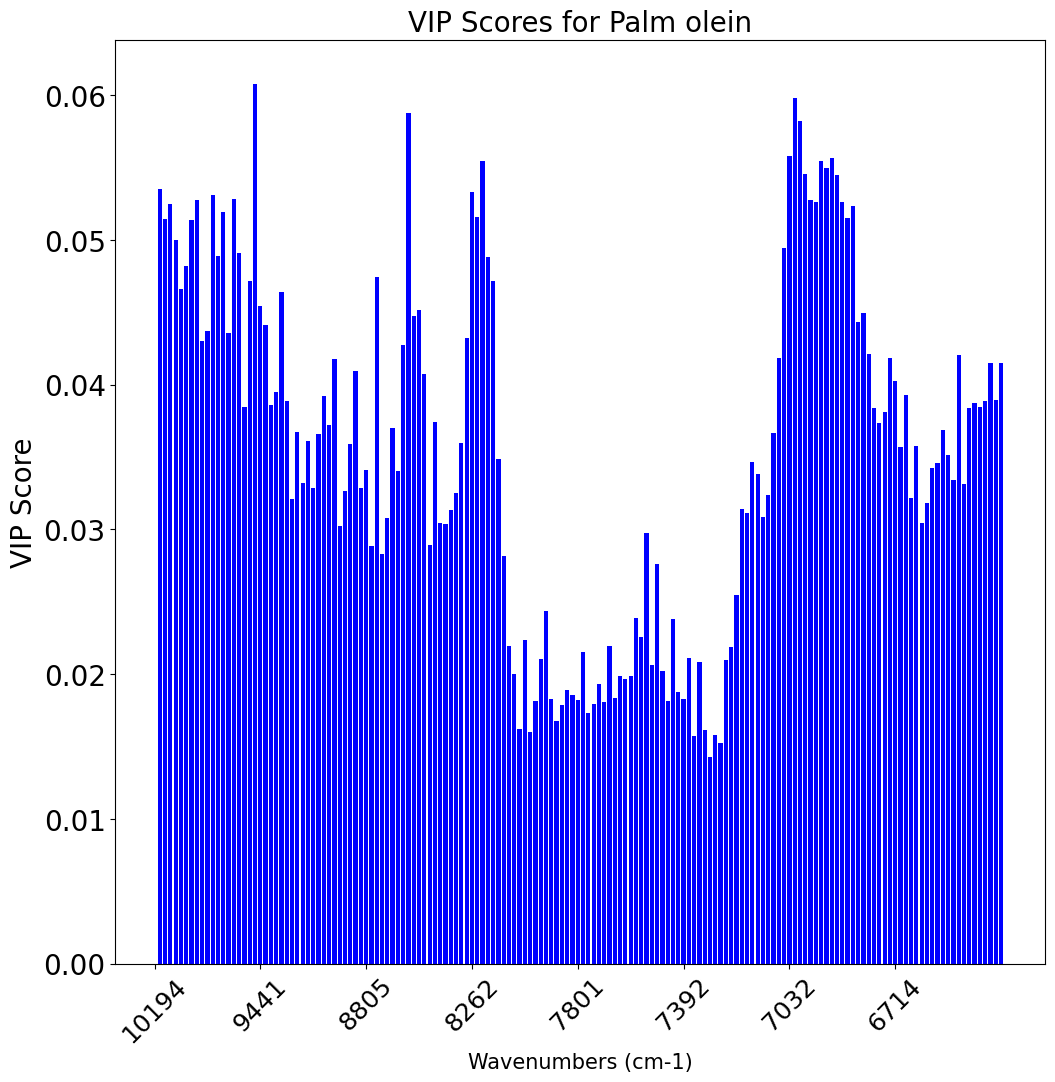

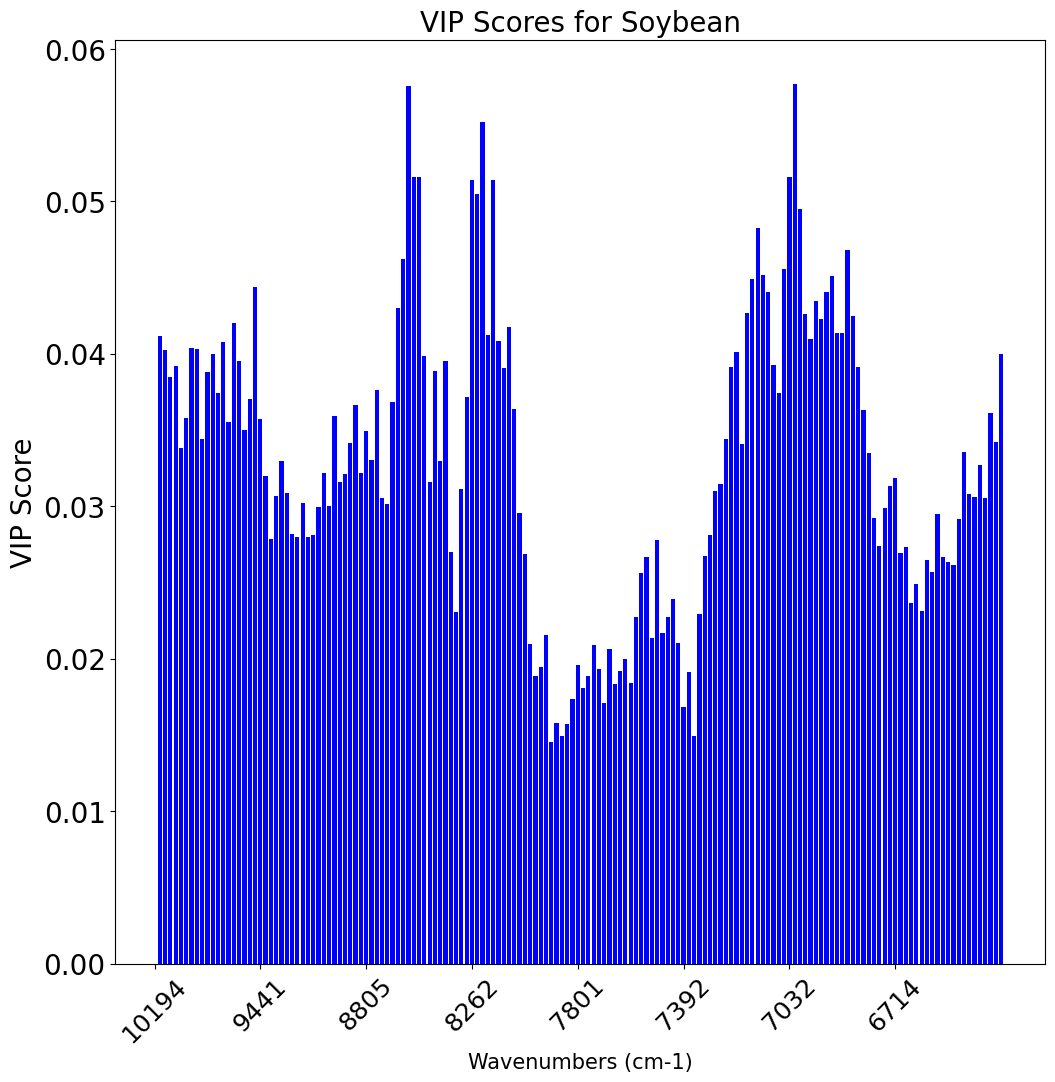

[15, 'mc + snv', 0.09, 0.96, 20, 180]

In [ ]:
ase.run_experiment(file, start_index=best_experiment["start_index"], end_index=best_experiment["end_index"], contamination=best_experiment["contamination"], combinacao=best_experiment["combinacao"],
                   plot=True, modelo="PLSDA", verbose=True, coluna_predicao="Adulterant")

# Plotting all solutions obtained

In [ ]:
import pandas as pd
!ls results
result = pd.read_csv("results/NIR1_Adulterant_best_PLSDA.csv")
result

'NIR1_Adulterant_Accuracy=0.95_PLSDA.png'	  NIR1_Canola_PLSDA_VIP.png
 NIR1_Adulterant_best_PLSDA.csv			  NIR1_mc_PCA.png
 NIR1_Adulterant_report_df_PLSDA.csv		 'NIR1_Palm olein_PLSDA_VIP.png'
'NIR1-Adulterant - RMSECV by LV - mc_PLSDA.png'   NIR1_Soybean_PLSDA_VIP.png


,file,cortar_extremidades,pre_processamento,contaminacao,best_n_components,accuracy,start_index,end_index
0,NIR1.csv,False,mc + d1,0.01,12,0.97,50,220
1,NIR1.csv,False,mc + d1,0.09,9,0.91,60,170
2,NIR1.csv,False,mc,0.08,16,0.91,40,160
3,NIR1.csv,False,mc + smo,0.13,18,0.95,50,230
4,NIR1.csv,False,mc + snv,0.04,13,0.93,60,170
...,...,...,...,...,...,...,...,...
990,NIR1.csv,False,mc + d2,0.07,13,0.91,0,210
991,NIR1.csv,False,mc + snv,0.10,13,0.86,20,130
992,NIR1.csv,False,mc + smo,0.15,12,0.93,20,160
993,NIR1.csv,False,mc + d1,0.08,12,0.90,30,140


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = result

# Set seaborn style for beautiful plots
sns.set(style="whitegrid")

# Create a ranking for 'pre_processamento' based on accuracy
pre_process_rank = df.groupby("pre_processamento")["accuracy"].mean().sort_values(ascending=False).reset_index()
# Create a ranking for 'contaminacao' based on accuracy
contamination_rank = df.groupby("contaminacao")["accuracy"].mean().sort_values(ascending=False).reset_index()
# Create a ranking for 'best_n_components' based on accuracy
best_n_rank = df.groupby("best_n_components")["accuracy"].mean().sort_values(ascending=False).reset_index()

### Best Pre-processing method

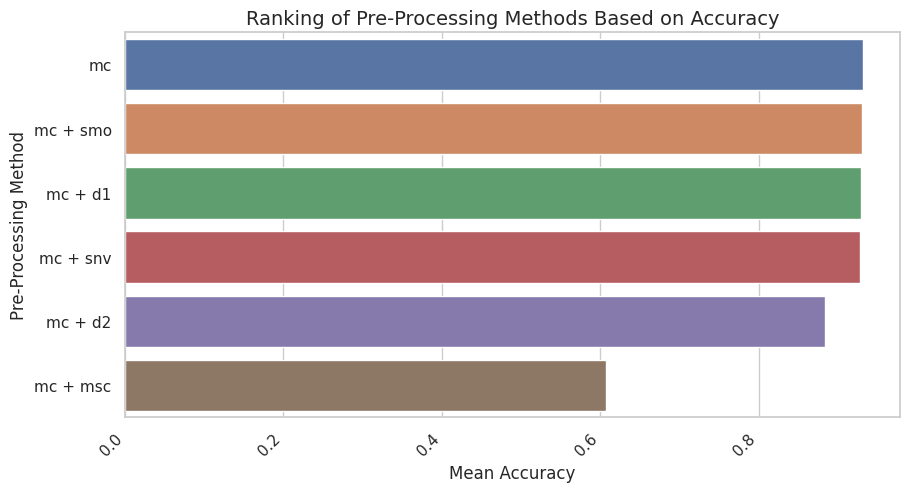

In [ ]:
# Pre-processing ranking
plt.figure(figsize=(10, 5))
sns.barplot(data=pre_process_rank, x="accuracy", y="pre_processamento", hue="pre_processamento", legend=False)
plt.title("Ranking of Pre-Processing Methods Based on Accuracy", fontsize=14)
plt.xlabel("Mean Accuracy")
plt.ylabel("Pre-Processing Method")
plt.xticks(rotation=45, ha='right')
plt.show()

### Best outlier removal parameter (contamination)

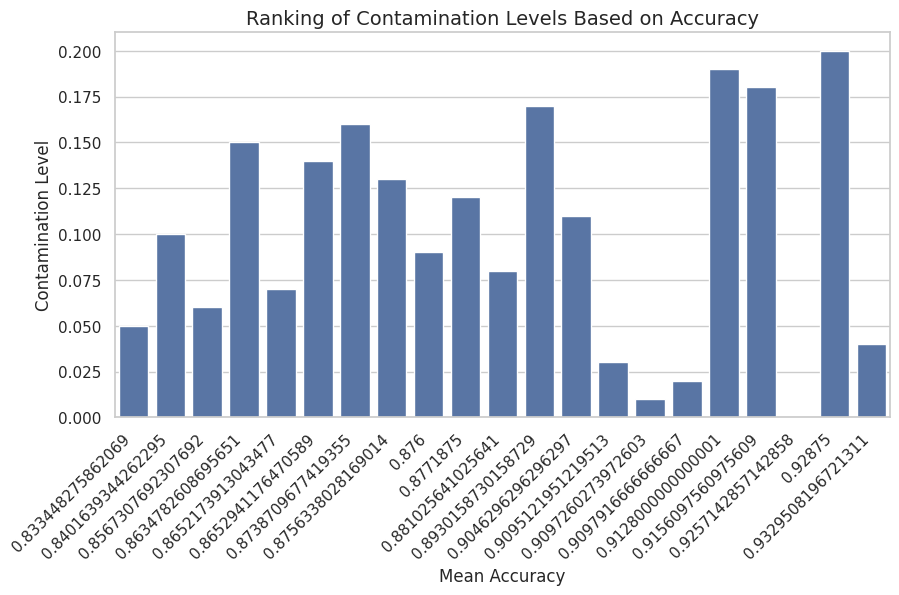

In [ ]:
# Contamination ranking
plt.figure(figsize=(10, 5))
sns.barplot(data=contamination_rank, x="accuracy", y="contaminacao")
plt.title("Ranking of Contamination Levels Based on Accuracy", fontsize=14)
plt.xlabel("Mean Accuracy")
plt.ylabel("Contamination Level")
plt.xticks(rotation=45, ha='right')
plt.show()

### Best LV number

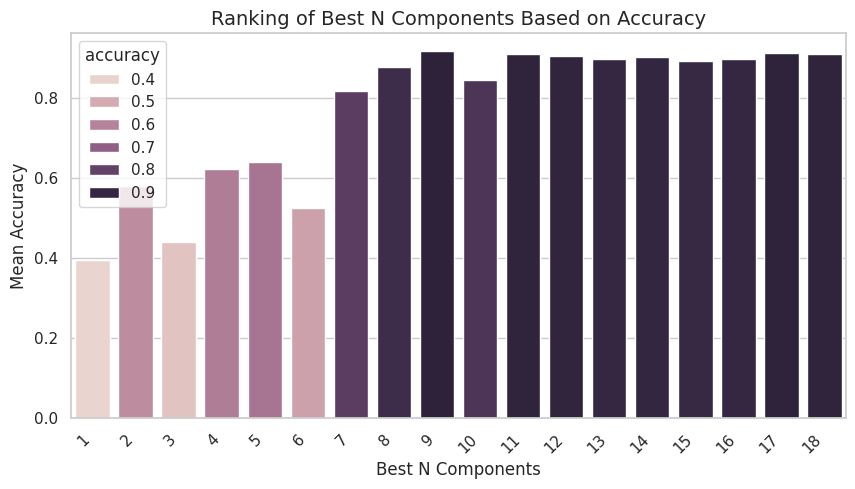

In [ ]:
# Best N Components ranking
plt.figure(figsize=(10, 5))
sns.barplot(data=best_n_rank, x="best_n_components", y="accuracy", hue="accuracy")
plt.title("Ranking of Best N Components Based on Accuracy", fontsize=14)
plt.xlabel("Best N Components")
plt.ylabel("Mean Accuracy")
plt.xticks(rotation=45, ha='right')
plt.show()


### Best Spectra window

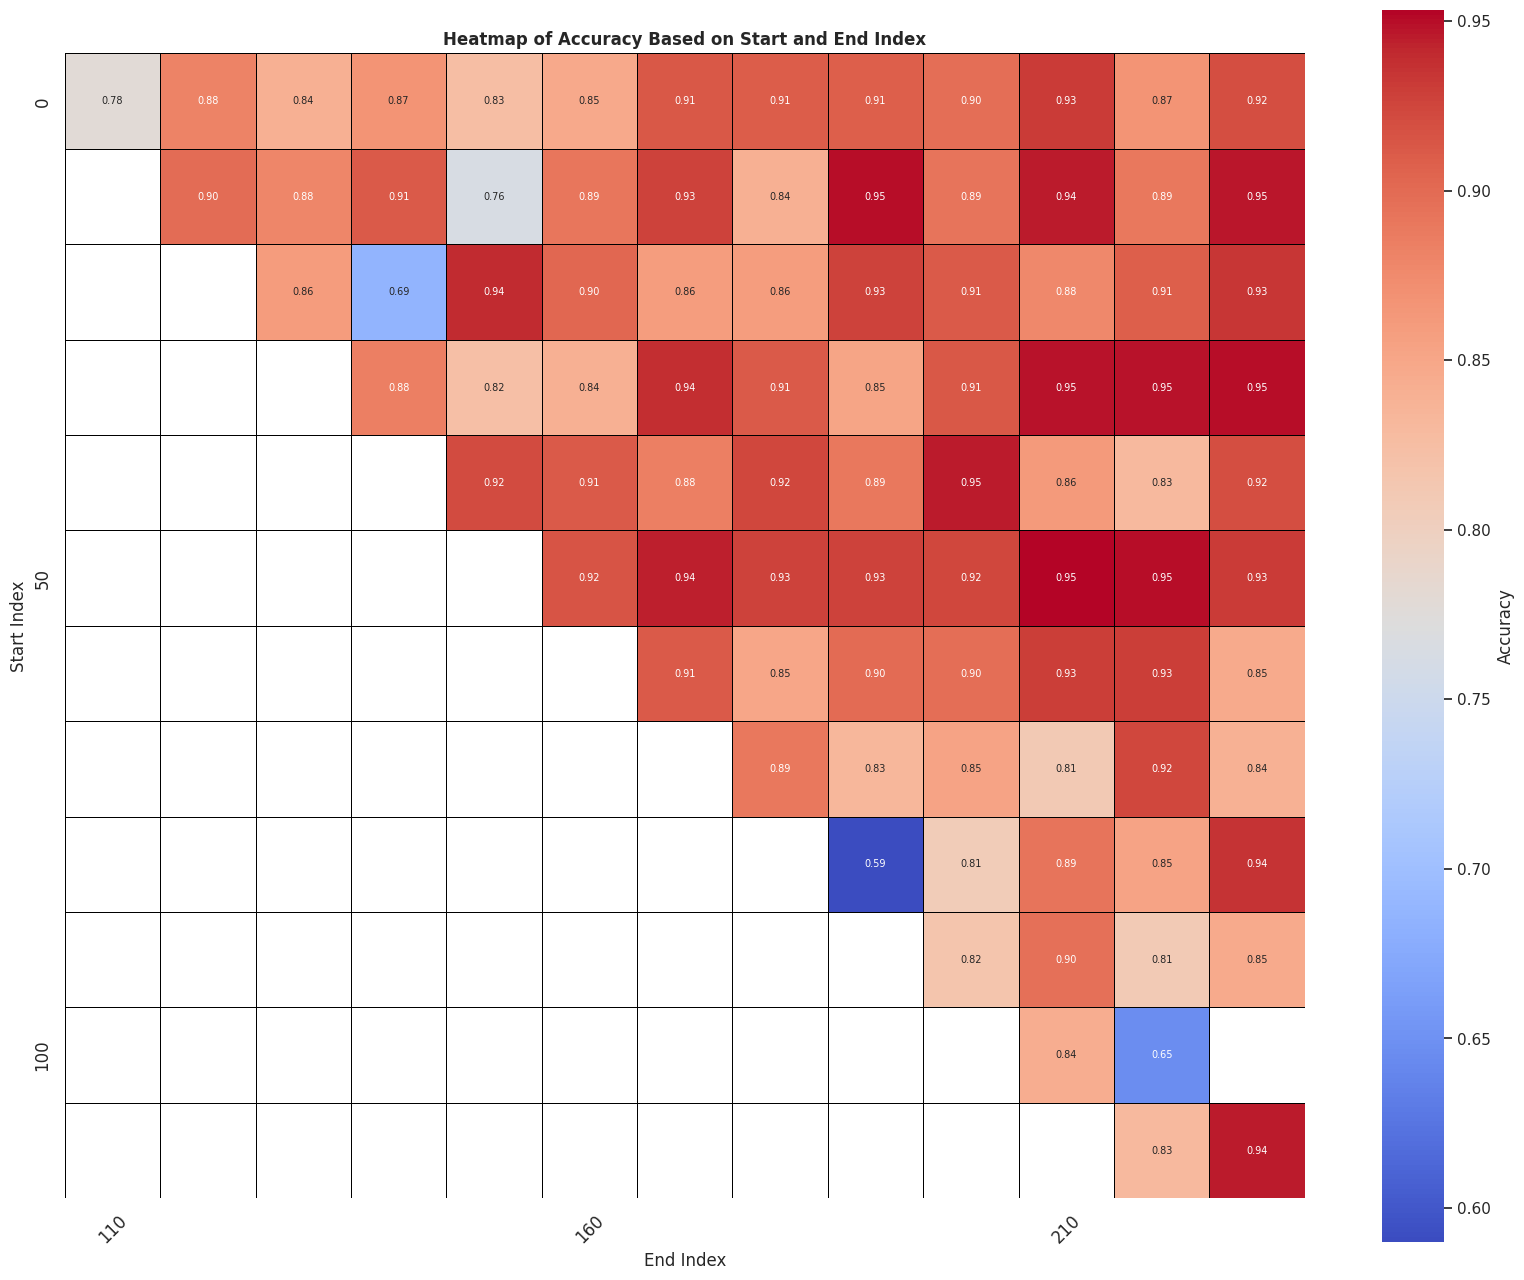

In [ ]:
heatmap_data = df.pivot_table(index="start_index", columns="end_index", values="accuracy", aggfunc="mean")

# Improve heatmap visualization by removing the gray grid background
plt.figure(figsize=(20, 16))

# Set a white background to remove the grid effect
sns.set_style("white")

# Create a refined heatmap with better contrast and labels
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Accuracy'},
    xticklabels=5,
    yticklabels=5,
    square=True,
    annot_kws={"size": 7}
)

plt.title("Heatmap of Accuracy Based on Start and End Index", fontsize=12, fontweight='bold')
plt.xlabel("End Index", fontsize=12)
plt.ylabel("Start Index", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Display the improved heatmap
plt.show()
